# Predicción de Series Temporales sobre el Dataset M5 Forecasting – Accuracy

**Trabajo Fin de Grado en Ciencia de Datos**

---

## Descripción

Este notebook contiene la implementación experimental del Trabajo Fin de Grado dedicado a la comparación de modelos de predicción de demanda sobre el dataset M5 Forecasting – Accuracy de Walmart. El dataset, compuesto por más de 58 millones de registros distribuidos en 30.490 series temporales jerárquicas, constituye una de las referencias canónicas en pronóstico de demanda minorista (Makridakis, Spiliotis & Assimakopoulos, 2022).

Se evalúan cinco modelos de naturaleza heterogénea: un baseline trivial (Naive Estacional), dos modelos estadísticos clásicos (ARIMA, SARIMA), un modelo aditivo descomponible (Prophet) y un algoritmo de aprendizaje automático basado en *Gradient Boosting* (XGBoost). La comparación se realiza sobre dos planos: la serie agregada de la tienda CA_1, donde los cinco modelos resultan aplicables en condiciones equivalentes, y el dataset completo a nivel SKU, donde únicamente los algoritmos diseñados para operar a escala granular conservan su viabilidad.

El detalle metodológico completo, la fundamentación teórica de cada modelo y la discusión de los resultados se encuentran en la memoria escrita del TFG, a la que este notebook acompaña como soporte experimental reproducible.

---

## Estructura del notebook

| Sección | Contenido | Apartado en la memoria |
|---------|-----------|------------------------|
| 0 | Configuración del entorno | 4.1 |
| 1 | Carga e inspección inicial del dataset | 4.1 |
| 2 | Optimización de memoria | 4.2 |
| 3 | Construcción del dataset maestro | 4.2 |
| 4 | Análisis exploratorio de datos (EDA) | 5.1 |
| 5 | Ingeniería de características | 5.4.1 |
| 6 | Evaluación de los cinco modelos sobre CA_1 | 5.1 – 5.4 |
| 7 | Escalado al dataset completo | 5.4.3 |
| 8 | Comparación final | 5.5 |

---

## Reproducibilidad

La fijación explícita de la semilla aleatoria (`SEED = 42`) y el uso de un entorno computacional estable (Kaggle Kernels) garantizan que la ejecución de este notebook produzca resultados idénticos a los reportados en la memoria escrita. El dataset original se encuentra disponible en la página oficial de la competición:

https://www.kaggle.com/competitions/m5-forecasting-accuracy/data

---

## Nota de transparencia sobre el uso de inteligencia artificial

Conforme a las recomendaciones éticas vigentes para la elaboración de trabajos académicos asistidos por inteligencia artificial, conviene declarar de forma explícita el alcance del uso de asistentes de IA en el desarrollo de este trabajo.

La autoría intelectual del análisis, la selección de modelos, las decisiones metodológicas y la interpretación de los resultados corresponden íntegramente al autor del TFG. El uso de herramientas de IA generativa se ha limitado a tres funciones de apoyo:

1. **Depuración de código:** identificación de errores sintácticos y de tipo (por ejemplo, incompatibilidades entre versiones de NumPy y pandas), así como sugerencias de optimización.
2. **Búsqueda de referencias bibliográficas:** localización de fuentes académicas que respalden las decisiones metodológicas adoptadas, siempre sometidas a verificación posterior por el autor.
3. **Revisión estilística:** mejora de la redacción para garantizar el cumplimiento de los criterios de estilo impersonal exigidos por la guía docente del TFG.

En ningún caso se ha utilizado IA para generar las decisiones de modelado, los análisis interpretativos ni las conclusiones del trabajo. La función `reduce_mem_usage` empleada en el apartado 2 constituye una adaptación de la rutina publicada por Groen (2017) en la comunidad Kaggle, citada formalmente tanto en este notebook como en la memoria escrita.

---

## Autor

Álvaro Tébar — Grado en Ciencia de Datos


---

# 0. Configuración del Entorno

Esta primera sección establece el entorno computacional sobre el que se ejecuta el resto del notebook. Comprende la carga de las bibliotecas científicas necesarias, la fijación de la semilla aleatoria y la definición de las constantes globales que delimitan el horizonte temporal del experimento.

La fijación de `SEED = 42` resulta crítica para la reproducibilidad estricta de los resultados. Esta semilla controla las componentes aleatorias de XGBoost (muestreo de filas y columnas durante el entrenamiento) y de Prophet (inicialización del muestreador MCMC interno). Los modelos estadísticos clásicos (ARIMA, SARIMA) son deterministas y no dependen de la semilla, pero su comportamiento puede variar con la versión de la biblioteca `statsmodels`. Conviene señalar que la versión empleada se documenta en el archivo `requirements.txt` del repositorio público.

Las constantes `TRAIN_END_DAY`, `VALID_START_DAY` y `VALID_END_DAY` definen la partición temporal estricta del dataset. El horizonte de validación de 28 días se elige de forma deliberada para coincidir con el horizonte oficial de predicción de la competición M5 (Makridakis et al., 2022), lo que permite comparar los resultados obtenidos con los publicados por los participantes oficiales.

| Biblioteca | Propósito | Referencia |
|-----------|-----------|------------|
| `pandas` | Manipulación de datos tabulares | McKinney (2010) |
| `numpy` | Operaciones numéricas vectorizadas | Harris et al. (2020) |
| `matplotlib` | Visualización estática | Hunter (2007) |
| `statsmodels` | Modelos estadísticos (ARIMA, SARIMA) | Seabold & Perktold (2010) |
| `prophet` | Modelo aditivo descomponible | Taylor & Letham (2018) |
| `xgboost` | *Gradient Boosting* sobre árboles | Chen & Guestrin (2016) |
| `sklearn.metrics` | Cálculo de métricas de error | Pedregosa et al. (2011) |


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import gc
import warnings

warnings.filterwarnings('ignore')

# --- Constantes globales ---
BASE = '/kaggle/input/competitions/m5-forecasting-accuracy/'
SEED = 42
HORIZON = 28          # Días de horizonte de predicción (definido por M5)
TRAIN_END_DAY   = 1913    # Último día de entrenamiento (validation.csv)
VALID_START_DAY = 1914    # Primer día test ciego (evaluation.csv)
VALID_END_DAY   = 1941    # Último día test ciego
SEED = 42

print(f"Entrenamiento: días 1 a {TRAIN_END_DAY}")
print(f"Validación:    días {VALID_START_DAY} a {VALID_END_DAY} (test ciego M5)")

Entrenamiento: días 1 a 1913
Validación:    días 1914 a 1941 (test ciego M5)


---

# 1. Carga y Primera Inspección del Dataset

El dataset M5 Forecasting – Accuracy se distribuye en cuatro ficheros CSV que componen un modelo relacional en esquema de copo de nieve. En esta sección se cargan los tres ficheros necesarios para el análisis y se inspecciona su estructura inicial.

**Ficheros del dataset:**

- `sales_train_evaluation.csv`: matriz principal de ventas en formato ancho, con 30.490 filas (una por SKU) y 1.941 columnas correspondientes a los días `d_1` a `d_1941`. Es la versión extendida que incluye los días originalmente reservados para evaluación de la competición.
- `calendar.csv`: 1.969 filas correspondientes a cada día del horizonte completo (incluye 28 días futuros). Incorpora variables temporales (día de la semana, mes, año), identificadores de eventos festivos (Super Bowl, Navidad, etc.) e indicadores binarios del programa SNAP por estado.
- `sell_prices.csv`: 6.841.121 registros con la información semanal de precios de cada producto en cada tienda.

La elección de `sales_train_evaluation` frente a `sales_train_validation` resulta deliberada: este último contiene únicamente los primeros 1.913 días y no incluye el periodo posterior necesario para reproducir la evaluación oficial de la competición. Conviene destacar que esta diferencia constituye una fuente habitual de error en implementaciones que utilizan el dataset.

La inspección posterior permite verificar la integridad de los datos antes de cualquier transformación.


In [4]:
# 1.1 Carga de los tres ficheros principales 
sales    = pd.read_csv(BASE + 'sales_train_validation.csv')
calendar = pd.read_csv(BASE + 'calendar.csv')
prices   = pd.read_csv(BASE + 'sell_prices.csv')

# 1.2 Inspección de dimensiones
print("DIMENSIONES: ")
print(f"Ventas:    {sales.shape}   =  {sales.shape[0]:,} productos × {sales.shape[1]} columnas")
print(f"Calendario:{calendar.shape}  = {calendar.shape[0]:,} días × {calendar.shape[1]} columnas")
print(f"Precios:   {prices.shape}    = {prices.shape[0]:,} registros × {prices.shape[1]} columnas")

# 1.3 Inspección visual de las primeras filas
print("\nPRIMERAS FILAS: VENTAS")
print(sales.iloc[:, :10].head(3))   # Solo primeras 10 columnas para legibilidad

print("\nPRIMERAS FILAS: CALENDARIO")
print(calendar.head(3))

print("\nPRIMERAS FILAS: PRECIOS")
print(prices.head(3))

# 1.4 Verificación de valores nulos
print("\nVALORES NULOS: ")
print(f"Ventas:    {sales.isnull().sum().sum()} nulos")
print(f"Calendario:{calendar.isnull().sum().sum()} nulos")
print(f"Precios:   {prices.isnull().sum().sum()} nulos")

DIMENSIONES: 
Ventas:    (30490, 1919)   =  30,490 productos × 1919 columnas
Calendario:(1969, 14)  = 1,969 días × 14 columnas
Precios:   (6841121, 4)    = 6,841,121 registros × 4 columnas

PRIMERAS FILAS: VENTAS
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  
0       CA    0    0    0    0  
1       CA    0    0    0    0  
2       CA    0    0    0    0  

PRIMERAS FILAS: CALENDARIO
         date  wm_yr_wk   weekday  wday  month  year    d event_name_1  \
0  2011-01-29     11101  Saturday     1      1  2011  d_1          NaN   
1  2011-01-30     11101    Sunday     2      1  2011  d_2          NaN   
2  2011-01-31     11101    Monday     3      1  2011  d_3          NaN   

  event_t

---

# 2. Optimización de Memoria

Sin optimización previa, el dataset completo supera los 2 GB de memoria en el entorno por defecto de pandas, lo que provoca errores en plataformas con recursos limitados y ralentiza notablemente las operaciones posteriores. La causa principal reside en que pandas asigna por defecto los tipos numéricos más amplios (`int64`, `float64`), lo que resulta innecesario para variables cuyo rango efectivo es muy inferior al permitido por dichos tipos.

La función `reduce_mem_usage` que se define a continuación constituye una **adaptación de la rutina publicada por Groen (2017) en la comunidad Kaggle** durante la competición Zillow Prize, ampliamente reutilizada posteriormente en la literatura aplicada de ciencia de datos. La función opera del siguiente modo: recorre cada columna del DataFrame, calcula su rango observado (mínimo y máximo) mediante `pandas.Series.min()` y `pandas.Series.max()`, y consulta los límites exactos de cada tipo numérico a través de `numpy.iinfo` y `numpy.finfo` (Harris et al., 2020). Si el rango observado cabe dentro de un tipo más pequeño (`int8`, `int16`, `int32`, `float16` o `float32`), la columna se reasigna a ese tipo, reduciendo así su consumo de memoria a una fracción del original.

Adicionalmente, las columnas de tipo `object` (texto) se convierten al tipo `category` de pandas, especialmente eficaz cuando el número de valores únicos es reducido respecto al número total de filas (situación denominada *baja cardinalidad*). En el caso de la columna `item_id` del fichero de precios, los 3.049 valores únicos repartidos entre 6,8 millones de filas justifican una reducción de memoria del 95 %, la más elevada observada.

La función incorpora una guarda inicial (`if hasattr(col_type, 'name') and col_type.name == 'category'`) que se añadió tras observar que las columnas ya convertidas a `category` no permiten el cálculo directo de `min()` y `max()`. Esta adaptación constituye una mejora menor respecto a la rutina original de Groen y permite reutilizar la función sobre DataFrames parcialmente optimizados.

Las reducciones observadas son consistentes con las reportadas en la literatura: en torno al 75 % para `sales`, 95 % para `prices` y 50 % para `calendar`.


In [5]:
def reduce_mem_usage(df):
    """Reduce el tipo de dato de cada columna al mínimo necesario."""
    
    for col in df.columns:
        col_type = df[col].dtype
        
        # Si ya es categórico lo dejamos — no se puede calcular min/max
        if hasattr(col_type, 'name') and col_type.name == 'category':
            continue
        
        if col_type == object:
            df[col] = df[col].astype('category')
        else:
            c_min, c_max = df[col].min(), df[col].max()
            
            if str(col_type)[:3] == 'int':
                if   c_min > np.iinfo(np.int8).min  and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if   c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    return df

mem_antes = {
    'sales':    sales.memory_usage(deep=True).sum() / 1024**2,
    'calendar': calendar.memory_usage(deep=True).sum() / 1024**2,
    'prices':   prices.memory_usage(deep=True).sum() / 1024**2,
}

sales    = reduce_mem_usage(sales)
calendar = reduce_mem_usage(calendar)
prices   = reduce_mem_usage(prices)

mem_despues = {
    'sales':    sales.memory_usage(deep=True).sum() / 1024**2,
    'calendar': calendar.memory_usage(deep=True).sum() / 1024**2,
    'prices':   prices.memory_usage(deep=True).sum() / 1024**2,
}

for nombre in mem_antes:
    reduccion = (1 - mem_despues[nombre] / mem_antes[nombre]) * 100
    print(f"{nombre:10} {mem_antes[nombre]:7.1f} MB  →  {mem_despues[nombre]:6.1f} MB  ({reduccion:.0f}% reducción)")

sales        455.4 MB  →    97.3 MB  (79% reducción)
calendar       0.7 MB  →     0.4 MB  (44% reducción)
prices       853.1 MB  →    45.9 MB  (95% reducción)


---

# 3. Construcción del Dataset Maestro

El archivo `sales` se distribuye en **formato ancho** (*wide*): cada fila corresponde a un producto y cada columna a un día concreto. Esta organización resulta eficiente para almacenamiento pero incompatible con los algoritmos de aprendizaje automático supervisado, que requieren una observación por fila (McKinney, 2010). La transformación necesaria, conocida como cambio de formato *wide* a *long*, se realiza mediante la operación `melt` de pandas.

Tras la transformación, cada fila representa una observación única: la venta de un producto concreto en un día concreto. El número de filas pasa de 30.490 (productos) a 59,2 millones (productos × días).

A continuación se fusionan dos fuentes de información complementarias mediante operaciones `merge`:

1. **Variables temporales del calendario** (`calendar.csv`): se incorporan día de la semana, mes, año, indicadores SNAP por estado e identificadores de eventos festivos. Esta información permite al modelo capturar el efecto del calendario sobre la demanda.
2. **Precios semanales** (`sell_prices.csv`): se incorpora el precio de cada producto en cada tienda para cada semana del horizonte. La fusión se realiza por `(store_id, item_id, wm_yr_wk)`, donde `wm_yr_wk` es el identificador semanal del sistema de Walmart.

El resultado es un único DataFrame `sales_long` con todas las variables explicativas alineadas a nivel `(SKU, día)`. La aplicación final de `reduce_mem_usage` sobre el DataFrame fusionado mantiene el consumo de memoria dentro de los límites operativos.


In [6]:
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

sales_long = pd.melt(sales, id_vars=id_vars, var_name='d', value_name='sales')
del sales
gc.collect()

# La limpieza de 'd' debe hacerse ANTES del merge con calendar
# calendar usa 'd_1', 'd_2'... así que mantenemos el formato texto hasta después del merge
sales_long = sales_long.merge(calendar, on='d', how='left')
del calendar
gc.collect()

# Ahora sí extraemos el número, ya que calendar no lo necesita más
sales_long['d'] = sales_long['d'].str.replace('d_', '').astype(np.int16)

sales_long = sales_long.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del prices
gc.collect()

print(f"Dimensiones del dataset maestro: {sales_long.shape}")
print(f"Memoria RAM ocupada: {sales_long.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nColumnas disponibles:\n{list(sales_long.columns)}")

Dimensiones del dataset maestro: (58327370, 22)
Memoria RAM ocupada: 1672.5 MB

Columnas disponibles:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price']


---

# 4. Análisis Exploratorio de Datos (EDA)

Antes de construir cualquier modelo se procede al análisis estructural de la serie histórica. El objetivo no es meramente descriptivo: las decisiones metodológicas posteriores (elección de variables, parámetros estacionales, función de pérdida, particiones temporales) se fundamentan en los hallazgos del EDA. Esta orientación es coherente con la práctica recomendada en la literatura de pronóstico (Hyndman & Athanasopoulos, 2021), donde la fase exploratoria se considera condición necesaria para la elección informada del modelo.

El análisis se desarrolla a **dos niveles de agregación**:

1. **Nivel corporativo** (todas las tiendas y categorías agregadas): permite identificar tendencias estructurales del conjunto del negocio, ciclos macroeconómicos y patrones de calendario aplicables al ecosistema completo.
2. **Nivel SKU individual** (los 30.490 productos por separado): permite cuantificar la intermitencia, la dispersión de volúmenes y la heterogeneidad entre productos, características que determinarán la viabilidad de cada tipo de modelo.

Los **hallazgos clave** del EDA, desarrollados en detalle en los apartados subsiguientes del notebook y en la sección 5.1 de la memoria escrita, son:

- **Hallazgo 1:** existencia de una tendencia creciente sostenida a lo largo del horizonte histórico, junto con un cambio de régimen visible alrededor del día 1.000.
- **Hallazgo 2:** estacionalidad semanal dominante (m=7) con picos sistemáticos en fines de semana y mínimos en martes, patrón consistente con el comportamiento típico del consumo minorista.
- **Hallazgo 3:** alta intermitencia a nivel SKU, con un 68,2 % de los registros igual a cero, fenómeno que invalidará la aplicación directa de modelos estadísticos clásicos sobre series individuales.


## 4.1 Evolución temporal agregada

Se construye la serie diaria agregada a nivel corporativo (suma de las ventas de todos los SKUs cada día) y se visualiza el patrón temporal completo. Este nivel de agregación atenúa la intermitencia individual y permite observar con claridad la estructura macroscópica de la demanda.


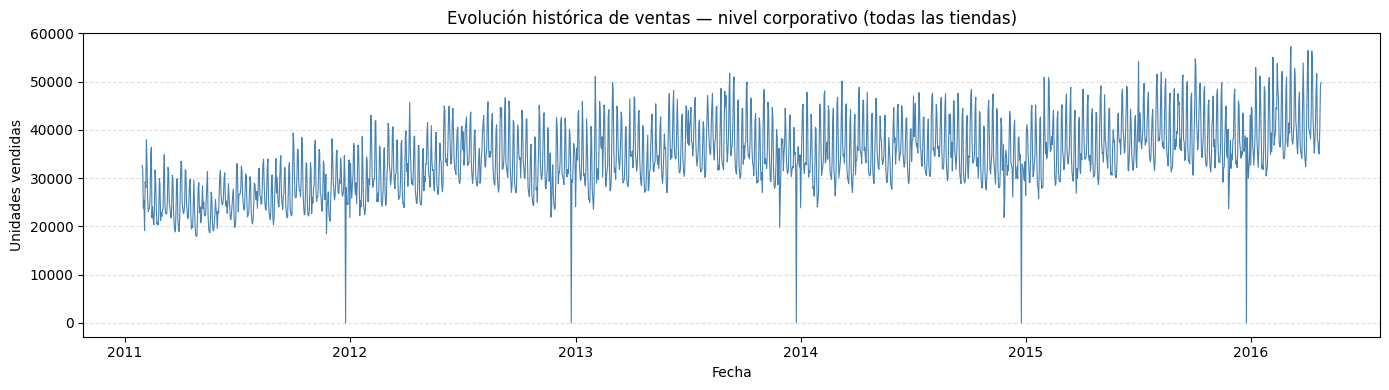

3101

In [7]:
# Agregación diaria a nivel corporativo
ventas_diarias = sales_long.groupby('d')['sales'].sum().reset_index()

# Recargamos calendar para asignar fechas reales al eje X
calendar_eda = pd.read_csv(BASE + 'calendar.csv')
calendar_eda['date'] = pd.to_datetime(calendar_eda['date'])
calendar_eda['d_num'] = calendar_eda['d'].str.replace('d_', '').astype(int)

ventas_diarias = ventas_diarias.merge(
    calendar_eda[['d_num', 'date']],
    left_on='d', right_on='d_num', how='left'
)

plt.figure(figsize=(14, 4))
plt.plot(ventas_diarias['date'], ventas_diarias['sales'],
         linewidth=0.8, color='steelblue')
plt.title('Evolución histórica de ventas — nivel corporativo (todas las tiendas)')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

del calendar_eda
gc.collect()

### 4.1.2 Estacionalidad semanal

Se calcula la media de ventas por día de la semana sobre el conjunto del histórico. El resultado permite identificar de forma directa el ciclo semanal (m=7) que será posteriormente explotado por SARIMA y por las variables `wday` de XGBoost. La clara diferencia entre el pico de fin de semana y los mínimos a mitad de semana motiva la decisión metodológica de emplear `seasonal=7` en SARIMA y de incluir `wday` como variable explícita en el conjunto de características de XGBoost.


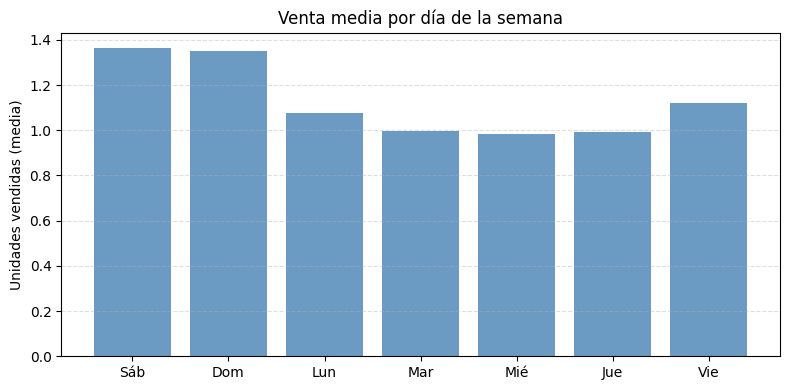

In [8]:
# La media de ventas por día de la semana revela el patrón semanal
ventas_por_dia_semana = sales_long.groupby('wday')['sales'].mean().reset_index()

# wday en M5: 1 = sábado, 2 = domingo, ..., 7 = viernes
dias = {1: 'Sáb', 2: 'Dom', 3: 'Lun', 4: 'Mar', 5: 'Mié', 6: 'Jue', 7: 'Vie'}
ventas_por_dia_semana['nombre'] = ventas_por_dia_semana['wday'].map(dias)

plt.figure(figsize=(8, 4))
plt.bar(ventas_por_dia_semana['nombre'], ventas_por_dia_semana['sales'], color='steelblue', alpha=0.8)
plt.title('Venta media por día de la semana')
plt.ylabel('Unidades vendidas (media)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 4.1.3 Distribución de ventas por categoría

Se descompone el volumen total de ventas por las tres categorías de producto del dataset (`FOODS`, `HOUSEHOLD`, `HOBBIES`). La distribución observada justifica el tratamiento conjunto de las tres categorías mediante un único modelo global de XGBoost, dado que el patrón de demanda relativo de cada categoría se conserva a lo largo del horizonte sin cambios estructurales que requieran modelos separados.


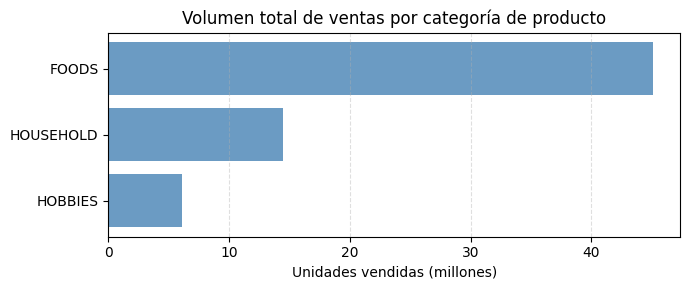

In [9]:
ventas_categoria = sales_long.groupby('cat_id')['sales'].sum().reset_index()
ventas_categoria = ventas_categoria.sort_values('sales', ascending=True)

# Convertimos a millones para que el eje sea legible
ventas_categoria['sales_M'] = ventas_categoria['sales'] / 1_000_000

plt.figure(figsize=(7, 3))
plt.barh(ventas_categoria['cat_id'], ventas_categoria['sales_M'], color='steelblue', alpha=0.8)
plt.title('Volumen total de ventas por categoría de producto')
plt.xlabel('Unidades vendidas (millones)')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 4.2 Descomposición STL

La descomposición STL (*Seasonal-Trend decomposition using Loess*) constituye una técnica clásica para separar una serie temporal en tres componentes ortogonales: tendencia, estacionalidad y residuo (Cleveland et al., 1990). A diferencia de la descomposición clásica, STL admite una estacionalidad de magnitud variable a lo largo del tiempo y resulta robusta frente a valores extremos, lo que la hace especialmente adecuada para series de ventas minoristas.

Se aplica la descomposición sobre la serie agregada total con `period=7` (estacionalidad semanal). Los tres paneles resultantes (tendencia, estacional y residuo) permiten cuantificar la tendencia subyacente independientemente del ruido semanal, aislar la componente estacional pura, e inspeccionar el residuo como diagnóstico de si la descomposición ha capturado adecuadamente la estructura de la serie.


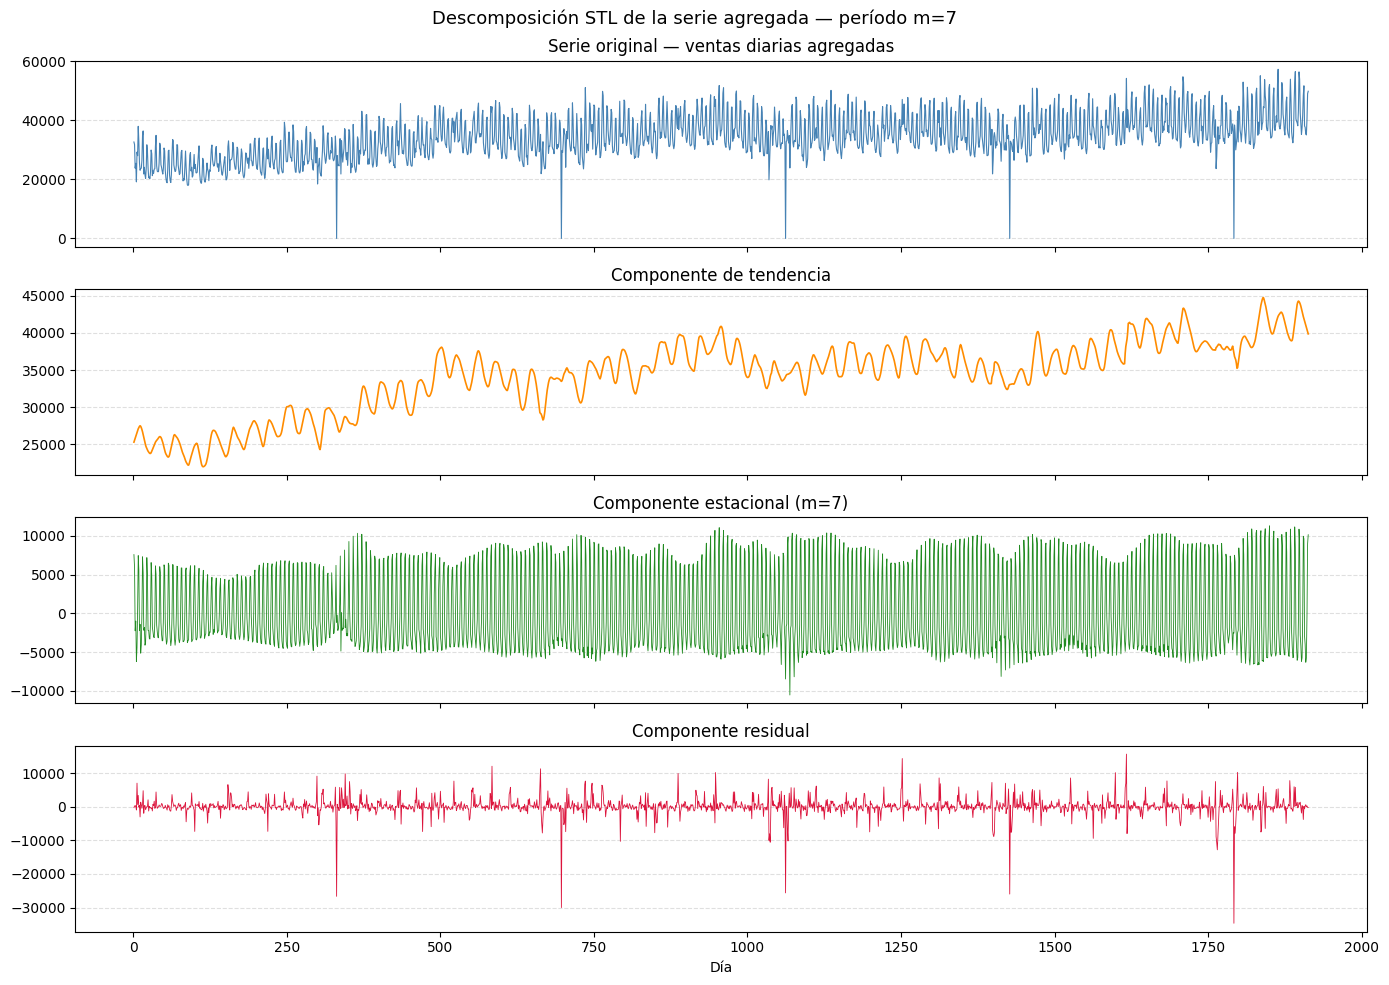

Amplitud del componente estacional: 21838 unidades
Varianza estacional / varianza residual: 3.67
(valores > 1 indican que la señal estacional domina sobre el ruido)


In [10]:
# Se descompone la serie agregada total en tendencia, estacionalidad y residuo mediante el algoritmo STL (Cleveland et al., 1990). 
from statsmodels.tsa.seasonal import STL

# La serie ventas_diarias ya se construyó en la celda anterior (4.1)
serie_stl = ventas_diarias.set_index('d')['sales']

stl = STL(serie_stl, period=7, robust=True)
resultado_stl = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(serie_stl.index, serie_stl.values, color='steelblue', linewidth=0.8)
axes[0].set_title('Serie original — ventas diarias agregadas')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].plot(serie_stl.index, resultado_stl.trend, color='darkorange', linewidth=1.2)
axes[1].set_title('Componente de tendencia')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

axes[2].plot(serie_stl.index, resultado_stl.seasonal, color='forestgreen', linewidth=0.6)
axes[2].set_title('Componente estacional (m=7)')
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

axes[3].plot(serie_stl.index, resultado_stl.resid, color='crimson', linewidth=0.6)
axes[3].set_title('Componente residual')
axes[3].set_xlabel('Día')
axes[3].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Descomposición STL de la serie agregada — período m=7', fontsize=13)
plt.tight_layout()
plt.show()

# Estadísticos del componente estacional para confirmar la hipótesis
amplitud_estacional = resultado_stl.seasonal.max() - resultado_stl.seasonal.min()
varianza_estacional = resultado_stl.seasonal.var()
varianza_residual = resultado_stl.resid.var()
ratio_senal_ruido = varianza_estacional / varianza_residual

print(f"Amplitud del componente estacional: {amplitud_estacional:.0f} unidades")
print(f"Varianza estacional / varianza residual: {ratio_senal_ruido:.2f}")
print(f"(valores > 1 indican que la señal estacional domina sobre el ruido)")

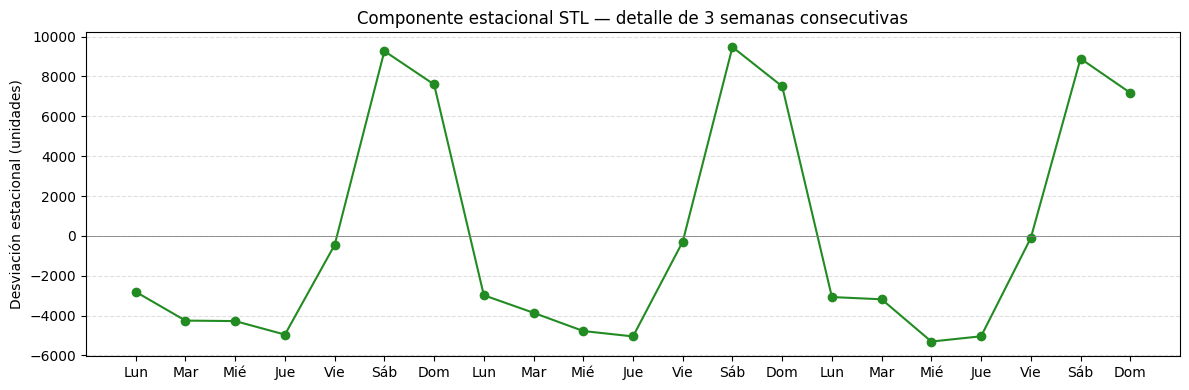

In [11]:
# Se toman 21 días consecutivos (3 semanas) en una zona central del dataset
inicio = 1003  # lunes
fin = inicio + 21  # 3 semanas completas

dias_semana = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'] * 3

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(inicio, fin), resultado_stl.seasonal[inicio:fin].values,
        marker='o', color='forestgreen', linewidth=1.5)
ax.set_xticks(range(inicio, fin))
ax.set_xticklabels(dias_semana, rotation=0)
ax.set_title('Componente estacional STL — detalle de 3 semanas consecutivas')
ax.set_ylabel('Desviación estacional (unidades)')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.axhline(0, color='gray', linewidth=0.6)
plt.tight_layout()
plt.show()

## 4.3 Distribución de ventas a nivel SKU

Hasta este punto el análisis se ha realizado sobre series agregadas. En este subapartado se cambia el nivel de análisis al **producto individual** para cuantificar la intermitencia de la demanda, característica que condicionará completamente las decisiones de modelado posteriores.

Se aplana la matriz completa de ventas de los 30.490 SKUs sobre los 1.941 días, generando un vector único de aproximadamente 59,2 millones de observaciones. Sobre ese vector se calcula la frecuencia relativa de los valores 0, 1, 2, 3, 4 y ≥5 unidades por producto y día. El resultado constituye el **Hallazgo 3** del EDA: aproximadamente el 68 % de las observaciones son cero, fenómeno conocido en la literatura como *demanda intermitente* (Croston, 1972; Syntetos & Boylan, 2005).

Esta característica tiene tres consecuencias directas sobre la elección de modelos:

1. **Invalida los supuestos de ARIMA y SARIMA** a nivel SKU individual, dado que estos modelos asumen series continuas con distribución aproximadamente normal del error.
2. **Justifica el uso de la función de pérdida Tweedie** en XGBoost, específicamente diseñada para distribuciones que combinan una masa concentrada en cero con una cola de valores positivos continuos (Smyth & Jørgensen, 2002).
3. **Invalida el uso del MAPE** como métrica de evaluación, dado que su fórmula implica una división por el valor real y la división por cero produce un valor indefinido. Esta es la razón por la que se utiliza el RMSE como métrica principal.


Observaciones totales:    58,327,370
Observaciones con valor 0: 39,777,094
Porcentaje de ceros:       68.20%
Media de ventas por SKU/día: 1.126 unidades
Mediana:                     0 unidades
Percentil 90:                3 unidades


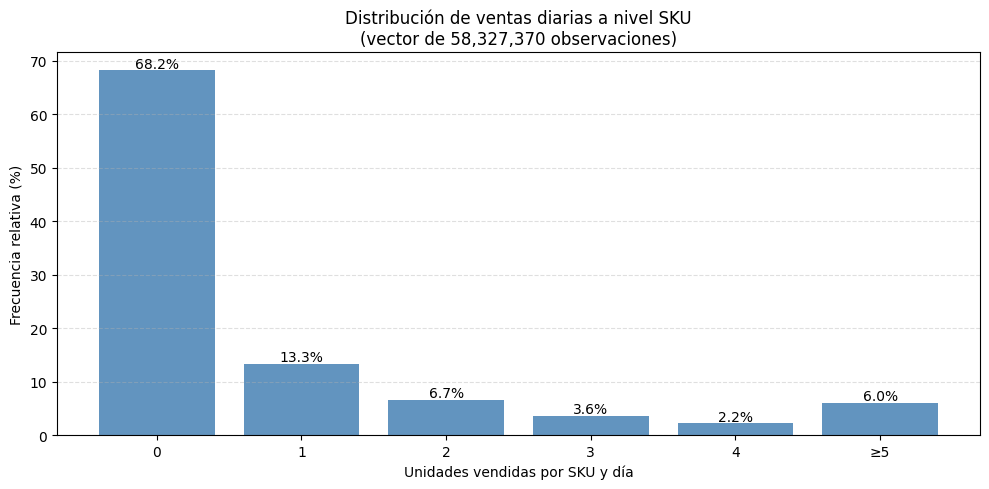

4812

In [12]:
# Se aplana la matriz completa de ventas en un vector de 59.180.090  observaciones y se calcula la frecuencia relativa de cada valor.
# Se cargan las ventas en formato ancho (sin melt)
sales_raw = pd.read_csv(BASE + 'sales_train_validation.csv')
dia_cols = [col for col in sales_raw.columns if col.startswith('d_')]

# Se aplana la matriz 30.490 x 1.941 en un vector único
vector_ventas = sales_raw[dia_cols].values.flatten()

del sales_raw
gc.collect()

# Estadísticos descriptivos
n_total = len(vector_ventas)
n_ceros = (vector_ventas == 0).sum()
pct_ceros = n_ceros / n_total * 100

print(f"Observaciones totales:    {n_total:,}")
print(f"Observaciones con valor 0: {n_ceros:,}")
print(f"Porcentaje de ceros:       {pct_ceros:.2f}%")
print(f"Media de ventas por SKU/día: {vector_ventas.mean():.3f} unidades")
print(f"Mediana:                     {np.median(vector_ventas):.0f} unidades")
print(f"Percentil 90:                {np.percentile(vector_ventas, 90):.0f} unidades")

# Distribución de frecuencias para valores 0, 1, 2, 3, 4 y >=5
bins = [0, 1, 2, 3, 4, 5, vector_ventas.max() + 1]
labels = ['0', '1', '2', '3', '4', '≥5']
frecuencias, _ = np.histogram(vector_ventas, bins=bins)
frecuencias_pct = frecuencias / n_total * 100

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.bar(labels, frecuencias_pct, color='steelblue', alpha=0.85)
ax.set_title('Distribución de ventas diarias a nivel SKU\n'
             f'(vector de {n_total:,} observaciones)')
ax.set_xlabel('Unidades vendidas por SKU y día')
ax.set_ylabel('Frecuencia relativa (%)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Etiquetas sobre cada barra
for barra, pct in zip(barras, frecuencias_pct):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

del vector_ventas
gc.collect()

---

# 5. Ingeniería de Características (Feature Engineering)

Los algoritmos de aprendizaje automático no operan directamente sobre series temporales: requieren que la información temporal sea transformada en un conjunto de columnas numéricas estáticas. Esta transformación, denominada *feature engineering*, es la fase que con frecuencia distingue un modelo efectivo de uno ineficiente (Januschowski et al., 2020).

Se construyen dos tipos de características temporales fundamentales:

**Variables de retraso (*lag features*):**

- `lag_28`: ventas registradas exactamente 28 días antes del día objetivo.
- `lag_35`: ventas registradas exactamente 35 días antes del día objetivo.

La elección de **retardos múltiplos de siete** (28 = 4×7, 35 = 5×7) garantiza que el modelo compare siempre días equivalentes de la semana, alineándose con la estacionalidad semanal identificada en el EDA. Adicionalmente, la elección de retardos **iguales o superiores al horizonte de predicción** (28 días) responde a una restricción operativa: cualquier retardo inferior a 28 no estaría disponible en el momento real de la predicción, lo que constituiría una fuga de información del futuro (*data leakage*), uno de los errores metodológicos más frecuentes en pronóstico de series temporales (Bergmeir, Hyndman & Koo, 2018).

**Medias móviles (*rolling mean features*):**

- `rmean_28_7`: media de las siete observaciones anteriores con origen en `lag_28`.
- `rmean_28_28`: media de las veintiocho observaciones anteriores con origen en `lag_28`.

Estas variables capturan la **tendencia local** del producto suavizando el ruido idiosincrático de cada día concreto. El cálculo sobre `lag_28` (en lugar de sobre `sales` directamente) resulta crítico para evitar la fuga de información.

El parámetro `min_periods=1` evita la propagación de valores nulos al inicio de la ventana móvil cuando hay menos observaciones disponibles que el tamaño de la ventana.


In [13]:
# Se ordena por producto y día antes de calcular cualquier característica temporal
# Sin este orden los lags se calcularían sobre filas incorrectas
sales_long = sales_long.sort_values(['id', 'd']).reset_index(drop=True)

# --- Lag features ---
# lag_28: ventas de hace exactamente 4 semanas (mismo día de la semana)
# lag_35: ventas de hace exactamente 5 semanas
sales_long['lag_28'] = sales_long.groupby('id')['sales'].shift(28)
sales_long['lag_35'] = sales_long.groupby('id')['sales'].shift(35)

# --- Rolling mean features ---
# rmean_28_7:  media de las últimas 7 observaciones con origen en lag_28
# rmean_28_28: media de las últimas 28 observaciones con origen en lag_28
# min_periods=1 evita nulos cuando hay menos observaciones que la ventana
sales_long['rmean_28_7']  = sales_long.groupby('id')['lag_28'].transform(
    lambda x: x.rolling(window=7,  min_periods=1).mean()
)
sales_long['rmean_28_28'] = sales_long.groupby('id')['lag_28'].transform(
    lambda x: x.rolling(window=28, min_periods=1).mean()
)

# Las primeras filas de cada producto tendrán nulos en los lags
# Se eliminan las filas sin lag_28 ya que son inutilizables para el entrenamiento
sales_long = sales_long.dropna(subset=['lag_28', 'lag_35'])
sales_long = reduce_mem_usage(sales_long)

print(f"Dimensiones tras feature engineering: {sales_long.shape}")
print(f"Características disponibles: {list(sales_long.columns)}")

Dimensiones tras feature engineering: (57260220, 26)
Características disponibles: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'lag_28', 'lag_35', 'rmean_28_7', 'rmean_28_28']


---

# 6. Extracción de la Serie CA_1

Antes de escalar el análisis al dataset completo (30.490 series individuales), los cinco modelos se evalúan sobre una **única serie temporal agregada**: las ventas diarias totales de la tienda CA_1, obtenidas como la suma diaria de los 3.049 productos de esa tienda. Este enfoque permite una comparación controlada en condiciones idénticas para los cinco modelos.

La elección de la tienda CA_1 responde a tres motivos:

1. **Mayor volumen de ventas** entre las tiendas de California, el estado con mayor peso relativo en el dataset.
2. **Continuidad operativa completa**: la tienda registra ventas no nulas todos los días del horizonte histórico, condición necesaria para la aplicabilidad de ARIMA y SARIMA.
3. **Patrón estacional semanal claramente identificable**, una vez agregadas las 3.049 series individuales.

La partición temporal es **idéntica para los cinco modelos**: entrenamiento sobre los días 1 a 1.885 y validación sobre los días 1.886 a 1.913 (28 días), coincidiendo con el horizonte oficial de predicción de la competición M5 (Makridakis et al., 2022).


In [14]:
# Se carga evaluation solo para CA_1 — sales_long ya fue eliminado
eval_raw = pd.read_csv(BASE + 'sales_train_evaluation.csv')
ca1_raw  = eval_raw[eval_raw['store_id'] == 'CA_1']
dia_cols = [col for col in ca1_raw.columns if col.startswith('d_')]
ca1_agg  = ca1_raw[dia_cols].sum()

serie_ca1 = pd.DataFrame({
    'ds': pd.date_range(start='2011-01-29', periods=len(ca1_agg), freq='D'),
    'd':  range(1, len(ca1_agg) + 1),
    'y':  ca1_agg.values
})

train_ca1 = serie_ca1[serie_ca1['d'] <= TRAIN_END_DAY].copy()
valid_ca1 = serie_ca1[(serie_ca1['d'] >= VALID_START_DAY) & (serie_ca1['d'] <= VALID_END_DAY)].copy()

del eval_raw, ca1_raw, ca1_agg
gc.collect()

print(f"Días de entrenamiento: {len(train_ca1)}")
print(f"Días de validación:    {len(valid_ca1)}")

del sales_long
gc.collect()

Días de entrenamiento: 1913
Días de validación:    28


0

## 6.1 Naive Estacional

El modelo Naive Estacional constituye la **referencia mínima de rendimiento** (*baseline*) sobre la que se mide el valor añadido de los modelos más sofisticados. Su lógica es trivial: la predicción para el día *t* es igual a las ventas observadas exactamente 28 días antes (`y_t = y_{t-28}`). El retardo de 28 días, alineado con el horizonte oficial de la competición M5, garantiza que la variable utilizada siempre esté disponible en el momento de la predicción y respeta el principio de causalidad temporal.

No existe entrenamiento — se trata de una heurística directa sin parámetros ajustables. Su función en el experimento es doble: establecer el listón mínimo (si un modelo algorítmico no supera esta referencia, su coste computacional no resulta justificable, según Hyndman & Athanasopoulos, 2021) y validar la calidad del EDA (el rendimiento del Naive cuantifica empíricamente cuánta información contiene la estacionalidad semanal por sí sola).


In [15]:
from sklearn.metrics import mean_squared_error

# La predicción es simplemente el valor de hace 28 días
naive_preds = train_ca1['y'].values[-28:]

rmse_naive = np.sqrt(mean_squared_error(valid_ca1['y'].values, naive_preds))

print(f"RMSE Naive Estacional (CA_1): {rmse_naive:.2f}")

RMSE Naive Estacional (CA_1): 433.53


## 6.2 ARIMA

ARIMA (*Autoregressive Integrated Moving Average*) es un modelo estadístico clásico introducido por Box y Jenkins (1970) que combina tres componentes:

- **AR (p):** componente autorregresiva, utiliza los *p* valores anteriores de la serie para predecir el valor actual.
- **I (d):** componente integrada, indica el número de diferenciaciones necesarias para hacer la serie estacionaria.
- **MA (q):** componente de media móvil, utiliza los *q* errores de predicción anteriores como información adicional.

La selección del orden `(p, d, q)` se realiza mediante búsqueda automática por criterio de información de Akaike (AIC, Akaike 1974), siguiendo la metodología clásica de Box-Jenkins. La búsqueda se acota a rangos moderados para mantener un tiempo de cómputo razonable.

El resultado esperable es revelador: ARIMA aplicado sobre una serie con estacionalidad semanal dominante **obtiene un error mayor que el Baseline Naive Estacional**, lo que evidencia empíricamente la limitación estructural de no incorporar un componente estacional explícito. Esta es precisamente la motivación de SARIMA en el apartado siguiente.


In [16]:
from statsmodels.tsa.arima.model import ARIMA
import itertools

# Búsqueda del orden óptimo (p, d, q) por AIC
# Limitamos el rango para que el tiempo de cómputo sea razonable
mejor_aic  = np.inf
mejor_orden = None

for p, d, q in itertools.product(range(0, 3), range(0, 2), range(0, 3)):
    try:
        modelo = ARIMA(train_ca1['y'], order=(p, d, q)).fit()
        if modelo.aic < mejor_aic:
            mejor_aic   = modelo.aic
            mejor_orden = (p, d, q)
    except:
        continue

print(f"Mejor orden ARIMA: {mejor_orden}  (AIC: {mejor_aic:.2f})")

# Entrenamiento con el orden óptimo
arima = ARIMA(train_ca1['y'], order=mejor_orden).fit()

# Predicción sobre los 28 días de validación
arima_preds = arima.forecast(steps=28)

rmse_arima = np.sqrt(mean_squared_error(valid_ca1['y'].values, arima_preds))
print(f"RMSE ARIMA (CA_1):            {rmse_arima:.2f}")
print(f"RMSE Naive Estacional (CA_1): {rmse_naive:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Mejor orden ARIMA: (2, 1, 2)  (AIC: 29980.75)
RMSE ARIMA (CA_1):            825.77
RMSE Naive Estacional (CA_1): 433.53


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 6.3 SARIMA

SARIMA (*Seasonal Autoregressive Integrated Moving Average*) extiende ARIMA incorporando un **componente estacional explícito**. El orden completo se denota `(p, d, q)(P, D, Q)_m`, donde los parámetros en mayúscula operan sobre el ciclo estacional de longitud *m*.

**Decisión metodológica: configuración fija frente a búsqueda automática.** Una primera aproximación al modelo SARIMA mediante búsqueda automática por AIC con `m=7` produjo un RMSE de 4.872,73 sobre el conjunto de validación, resultado que evidencia un fenómeno habitual en la optimización automática: el AIC puede identificar una combinación de parámetros que minimiza el error sobre el conjunto de entrenamiento, pero falla al generalizar a datos nuevos. Este resultado motivó el cambio de estrategia hacia una **configuración fija guiada por el EDA**, con orden `(1, 1, 1)(1, 1, 1)_7`:

- `(1, 1, 1)` no estacional: una componente autorregresiva, una diferenciación ordinaria (alineada con el Hallazgo 1) y una componente de media móvil.
- `(1, 1, 1)_7` estacional: una componente autorregresiva estacional, una diferenciación estacional (que elimina el ciclo semanal del Hallazgo 2) y una componente de media móvil estacional, todos sobre el periodo `m=7`.

El resultado obtenido sobre la serie de CA_1 confirma la importancia de la estacionalidad: SARIMA reduce el error de ARIMA a menos de la mitad y supera al Baseline Naive Estacional en aproximadamente un 10 %.


In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train_ca1['y'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_preds = sarima.forecast(steps=28)

rmse_sarima = np.sqrt(mean_squared_error(valid_ca1['y'].values, sarima_preds))
print(f"RMSE SARIMA (CA_1):           {rmse_sarima:.2f}")
print(f"RMSE ARIMA  (CA_1):           {rmse_arima:.2f}")
print(f"RMSE Naive Estacional (CA_1): {rmse_naive:.2f}")

RMSE SARIMA (CA_1):           388.26
RMSE ARIMA  (CA_1):           825.77
RMSE Naive Estacional (CA_1): 433.53


## 6.4 Prophet

Prophet es una biblioteca de predicción de series temporales desarrollada por Sean J. Taylor y Benjamin Letham en el equipo de ciencia de datos de Meta (Taylor & Letham, 2018). A diferencia de ARIMA y SARIMA, no requiere que la serie sea estacionaria ni la especificación manual de órdenes: la biblioteca descompone la serie automáticamente en tres componentes aditivas (tendencia, estacionalidad y efectos de calendario), lo que la sitúa en una tercera familia conceptualmente distinta: los **modelos aditivos descomponibles**.

Se activa explícitamente la estacionalidad semanal (`weekly_seasonality=True`), consistente con los patrones identificados en el EDA. Conviene destacar que el ajuste de los hiperparámetros se mantiene en sus valores por defecto, decisión coherente con la filosofía de diseño de Prophet, orientada a producir resultados razonables sin necesidad de ajuste manual experto.

El resultado obtenido sobre CA_1 constituye un hallazgo digno de análisis: Prophet queda **por debajo del Baseline Naive Estacional**, lo que contradice la expectativa inicial. La interpretación está respaldada por la literatura sobre modelos aditivos descomponibles: en series dominadas por un único ciclo estacional con horizonte corto, la arquitectura aditiva de Prophet penaliza la precisión punto a punto a cambio de interpretabilidad y robustez frente a cambios estructurales (Hewamalage, Bergmeir & Bandara, 2021; Triebe et al., 2021).


In [18]:
from prophet import Prophet

# Prophet requiere columnas con nombres exactos 'ds' y 'y'
# train_ca1 ya tiene ese formato desde la celda 7.0
modelo_prophet = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False
)

modelo_prophet.fit(train_ca1[['ds', 'y']])

# Generamos el dataframe de fechas futuras para los 28 días de validación
futuro = modelo_prophet.make_future_dataframe(periods=28)
forecast = modelo_prophet.predict(futuro)

# Extraemos solo las predicciones del horizonte de validación
prophet_preds = forecast.tail(28)['yhat'].values

rmse_prophet = np.sqrt(mean_squared_error(valid_ca1['y'].values, prophet_preds))
print(f"RMSE Prophet (CA_1):          {rmse_prophet:.2f}")
print(f"RMSE SARIMA  (CA_1):          {rmse_sarima:.2f}")
print(f"RMSE ARIMA   (CA_1):          {rmse_arima:.2f}")
print(f"RMSE Naive Estacional (CA_1): {rmse_naive:.2f}")

10:33:44 - cmdstanpy - INFO - Chain [1] start processing
10:33:45 - cmdstanpy - INFO - Chain [1] done processing


RMSE Prophet (CA_1):          500.15
RMSE SARIMA  (CA_1):          388.26
RMSE ARIMA   (CA_1):          825.77
RMSE Naive Estacional (CA_1): 433.53


## 6.5 XGBoost sobre CA_1

XGBoost se aplica sobre la misma serie agregada de CA_1 para establecer una comparación directa con los modelos estadísticos anteriores en condiciones equivalentes. A diferencia de ARIMA, SARIMA y Prophet, XGBoost **no trabaja directamente con la serie temporal**: requiere que la información temporal se transforme en características (apartado 5).

Se construyen sobre la serie de CA_1 los mismos *lags* (`lag_28`, `lag_35`) y medias móviles (`rmean_28_7`, `rmean_28_28`) ya empleados a nivel SKU, complementados con variables de calendario explícitas (`wday`, `month`, `year`).

**Hiperparámetros seleccionados (versión CA_1):**

- `objective: reg:tweedie` con `tweedie_variance_power: 1.1`: función de pérdida Tweedie para acomodar la asimetría natural de los datos de demanda (Smyth & Jørgensen, 2002).
- `max_depth: 6`: profundidad moderada de los árboles, suficiente para series univariantes sin riesgo de sobreajuste excesivo.
- `learning_rate: 0.05`: tasa de aprendizaje conservadora que prioriza la generalización sobre la velocidad de convergencia.
- `subsample: 0.8` y `colsample_bytree: 0.8`: muestreo estocástico de filas y columnas que actúa como regularización adicional.
- `min_child_weight: 10`: peso mínimo por hoja apropiado para una serie univariante.
- `early_stopping_rounds: 50`: detención temprana si no hay mejora durante 50 iteraciones consecutivas.

El resultado esperable es competitivo con SARIMA: ambos modelos operan sobre una serie agregada limpia, sin intermitencia y con autocorrelación a corto plazo dominante, escenario en el que SARIMA mantiene una pequeña ventaja estructural por explotar nativamente las dependencias autorregresivas.


In [19]:
# Se construyen las características sobre la serie CA_1
df_xgb = serie_ca1.copy()

df_xgb['lag_28']     = df_xgb['y'].shift(28)
df_xgb['lag_35']     = df_xgb['y'].shift(35)
df_xgb['rmean_28_7'] = df_xgb['lag_28'].rolling(window=7,  min_periods=1).mean()
df_xgb['rmean_28_28']= df_xgb['lag_28'].rolling(window=28, min_periods=1).mean()
df_xgb['wday']       = df_xgb['ds'].dt.dayofweek
df_xgb['month']      = df_xgb['ds'].dt.month
df_xgb['year']       = df_xgb['ds'].dt.year


# Se eliminan las filas sin lag_28
df_xgb = df_xgb.dropna(subset=['lag_28', 'lag_35'])

features_ca1 = ['lag_28', 'lag_35', 'rmean_28_7', 'rmean_28_28', 'wday', 'month', 'year']
train_xgb = df_xgb[df_xgb['d'] <= TRAIN_END_DAY]
valid_xgb = df_xgb[(df_xgb['d'] >= VALID_START_DAY) & (df_xgb['d'] <= VALID_END_DAY)]

print(f"Días de entrenamiento XGBoost: {len(train_xgb)}")
print(f"Días de validación XGBoost:    {len(valid_xgb)}")
dtrain_ca1 = xgb.DMatrix(train_xgb[features_ca1], label=train_xgb['y'])
dvalid_ca1 = xgb.DMatrix(valid_xgb[features_ca1], label=valid_xgb['y'])

params_ca1 = {
    'objective':              'reg:tweedie',
    'tweedie_variance_power': 1.1,
    'tree_method':            'hist',
    'learning_rate':          0.05,
    'max_depth':              6,
    'subsample':              0.8,
    'colsample_bytree':       0.8,
    'min_child_weight':       10,
    'seed':                   SEED
}

watchlist_ca1 = [(dtrain_ca1, 'train'), (dvalid_ca1, 'valid')]

model_ca1 = xgb.train(
    params_ca1,
    dtrain_ca1,
    num_boost_round=500,
    evals=watchlist_ca1,
    early_stopping_rounds=50,
    verbose_eval=50
)

xgb_preds_ca1 = model_ca1.predict(dvalid_ca1)

rmse_xgb_ca1 = np.sqrt(mean_squared_error(valid_xgb['y'].values, xgb_preds_ca1))
print(f"\nRMSE XGBoost (CA_1):          {rmse_xgb_ca1:.2f}")
print(f"RMSE SARIMA  (CA_1):          {rmse_sarima:.2f}")
print(f"RMSE Prophet (CA_1):          {rmse_prophet:.2f}")
print(f"RMSE Naive Estacional (CA_1): {rmse_naive:.2f}")
print(f"RMSE ARIMA   (CA_1):          {rmse_arima:.2f}")

Días de entrenamiento XGBoost: 1878
Días de validación XGBoost:    28
[0]	train-tweedie-nloglik@1.1:19561.11312	valid-tweedie-nloglik@1.1:22816.69622
[50]	train-tweedie-nloglik@1.1:19517.35670	valid-tweedie-nloglik@1.1:22764.63358
[100]	train-tweedie-nloglik@1.1:19514.60871	valid-tweedie-nloglik@1.1:22763.45585
[144]	train-tweedie-nloglik@1.1:19513.54732	valid-tweedie-nloglik@1.1:22763.78034

RMSE XGBoost (CA_1):          397.10
RMSE SARIMA  (CA_1):          388.26
RMSE Prophet (CA_1):          500.15
RMSE Naive Estacional (CA_1): 433.53
RMSE ARIMA   (CA_1):          825.77


## 6.6 Comparación directa sobre CA_1

Se presenta el resumen comparativo del error de predicción (RMSE) de los cinco modelos evaluados sobre la serie agregada de la tienda CA_1 en el horizonte de 28 días.

La interpretación detallada de estos resultados se desarrolla en el apartado 5.5 de la memoria escrita. Conviene destacar dos observaciones inmediatas:

1. **SARIMA y XGBoost ocupan las dos primeras posiciones** y son los únicos modelos que superan al Baseline Naive Estacional sobre esta serie.
2. **Prophet y ARIMA quedan por debajo del Baseline**, lo que constituye evidencia empírica de la importancia de incorporar correctamente la componente estacional al nivel de agregación adecuado.


In [20]:
resultados_ca1 = pd.DataFrame({
    'Modelo': ['SARIMA', 'Naive Estacional', 'XGBoost', 'Prophet', 'ARIMA'],
    'RMSE':   [rmse_sarima, rmse_naive, rmse_xgb_ca1, rmse_prophet, rmse_arima]
}).sort_values('RMSE').reset_index(drop=True)

resultados_ca1.index += 1  # Ranking empieza en 1
resultados_ca1['Mejora vs Naive (%)'] = (
    (rmse_naive - resultados_ca1['RMSE']) / rmse_naive * 100
).round(2)

media_validacion = valid_ca1['y'].mean()  # ← Media de los 28 días del test ciego
resultados_ca1['Error relativo real (%)'] = (resultados_ca1['RMSE'] / media_validacion * 100).round(2)

print(resultados_ca1.to_string())

             Modelo        RMSE  Mejora vs Naive (%)  Error relativo real (%)
1            SARIMA  388.255072                10.44                     8.11
2           XGBoost  397.097870                 8.40                     8.30
3  Naive Estacional  433.527928                 0.00                     9.06
4           Prophet  500.152060               -15.37                    10.45
5             ARIMA  825.771159               -90.48                    17.25


In [21]:
print(f"Media de train_ca1: {train_ca1['y'].mean():.2f}")

Media de train_ca1: 4024.16


---

# 7. Escalado al Dataset Completo

Los resultados anteriores se obtuvieron sobre una única serie agregada en condiciones controladas. En esta sección se escala el análisis al dataset completo (30.490 series individuales × 1.941 días = 59,2 millones de observaciones potenciales), que representa el problema real de predicción de demanda minorista a escala corporativa.

A esta escala los **modelos estadísticos clásicos (ARIMA, SARIMA) dejan de ser viables computacionalmente**: ajustar 30.490 modelos univariantes independientes resulta prohibitivo en términos de tiempo de cómputo y, lo que es más relevante, los modelos univariantes asumen series continuas, supuesto incompatible con el 68 % de ceros identificado en el EDA a nivel SKU (Box & Jenkins, 1970). La situación se invierte respecto al plano de CA_1: en el plano del SKU individual, el algoritmo de aprendizaje automático no solo es preferible sino que es el **único enfoque metodológicamente válido**.

Únicamente XGBoost y Prophet conservan su viabilidad a esta escala, aunque por motivos opuestos. XGBoost mediante una arquitectura de **modelo global** (un único modelo entrenado sobre todas las series simultáneamente que aprende relaciones compartidas entre productos), y Prophet mediante el ajuste sobre la **serie agregada corporativa** (la suma diaria de los 30.490 SKUs). Cabe señalar que esto implica una asimetría metodológica: XGBoost opera al nivel SKU y se agrega para comparación, mientras que Prophet opera directamente sobre la serie agregada. Esta asimetría se discute en detalle en el apartado 5.5 de la memoria.

Por su parte, el Naive Estacional se aplica a las 30.490 series individuales y posteriormente se agrega para permitir la comparación a nivel corporativo.


In [22]:
# Se reconstruye sales_long desde cero — fue eliminado en la celda 7.0
print("Cargando ficheros...")
sales = pd.read_csv(BASE + 'sales_train_evaluation.csv')
calendar = pd.read_csv(BASE + 'calendar.csv')
prices   = pd.read_csv(BASE + 'sell_prices.csv')

print("Optimizando memoria...")
sales    = reduce_mem_usage(sales)
calendar = reduce_mem_usage(calendar)
prices   = reduce_mem_usage(prices)

print("Construyendo dataset maestro...")
id_vars    = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
sales_long = pd.melt(sales, id_vars=id_vars, var_name='d', value_name='sales')
del sales
gc.collect()

sales_long = sales_long.merge(calendar, on='d', how='left')
del calendar
gc.collect()

sales_long['d'] = sales_long['d'].str.replace('d_', '').astype(np.int16)

sales_long = sales_long.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del prices
gc.collect()

print("Construyendo features...")
sales_long = sales_long.sort_values(['id', 'd']).reset_index(drop=True)

sales_long['lag_28']      = sales_long.groupby('id')['sales'].shift(28)
sales_long['lag_35']      = sales_long.groupby('id')['sales'].shift(35)
sales_long['rmean_28_7']  = sales_long.groupby('id')['lag_28'].transform(
    lambda x: x.rolling(window=7,  min_periods=1).mean()
)
sales_long['rmean_28_28'] = sales_long.groupby('id')['lag_28'].transform(
    lambda x: x.rolling(window=28, min_periods=1).mean()
)

sales_long = sales_long.dropna(subset=['lag_28', 'lag_35'])
sales_long = reduce_mem_usage(sales_long)

print(f"Dataset listo. Dimensiones: {sales_long.shape}")
print(f"Memoria RAM: {sales_long.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Cargando ficheros...
Optimizando memoria...
Construyendo dataset maestro...
Construyendo features...
Dataset listo. Dimensiones: (58113940, 26)
Memoria RAM: 2553.1 MB


## 7.1 XGBoost sobre el dataset completo

Se entrena un **único modelo global de XGBoost** que aprende simultáneamente sobre los 30.490 productos. Esta arquitectura permite al algoritmo extraer patrones compartidos entre series (efectos de calendario, comportamiento por categoría, sensibilidad al precio) que ningún modelo univariante puede capturar (Januschowski et al., 2020).

**Conjunto de características empleadas:**

- *Identificadores categóricos:* `item_id`, `dept_id`, `cat_id`, `store_id`, `state_id`.
- *Variables temporales:* `wday`, `month`, `year`. Capturan estacionalidad semanal, mensual e interanual.
- *Variables de demanda histórica:* `lag_28`, `lag_35`, `rmean_28_7`, `rmean_28_28` (construidas en el apartado 5).
- *Variables exógenas:* `sell_price` y los tres indicadores SNAP (`snap_CA`, `snap_TX`, `snap_WI`).

**Decisión metodológica: descarte de los primeros 1.000 días.** La partición de entrenamiento se restringe a los días `[1.000, 1.885]` en lugar de utilizar el histórico completo. Esta decisión responde a dos motivos: (i) el cambio de régimen identificado en el Hallazgo 1 del EDA hace que los datos previos al día 1.000 no resulten representativos del comportamiento contemporáneo, y (ii) el descarte reduce el coste de memoria sin pérdida de información relevante.

**Hiperparámetros adaptados a la escala:** `max_depth: 8` (frente a 6) para permitir interacciones más sofisticadas entre variables categóricas, `min_child_weight: 50` (frente a 10) para evitar particiones que generalicen mal en presencia de muchas categorías, y `num_boost_round: 1000` (frente a 500) para aprovechar el mayor volumen de datos. El resto de parámetros se mantiene constante respecto a la versión sobre CA_1.

La gestión explícita de memoria mediante `del` y `gc.collect()` resulta crítica a esta escala: la creación de las `DMatrix` de XGBoost duplica temporalmente el consumo de memoria, y la liberación de los DataFrames intermedios permite mantener la ejecución dentro de los límites del entorno computacional.


In [23]:
features = [
    'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
    'wday', 'month', 'year',
    'snap_CA', 'snap_TX', 'snap_WI',
    'sell_price',
    'lag_28', 'lag_35',
    'rmean_28_7', 'rmean_28_28'
]

train_mask = (sales_long['d'] >= 1000) & (sales_long['d'] <= TRAIN_END_DAY)
valid_mask = (sales_long['d'] >= VALID_START_DAY) & (sales_long['d'] <= VALID_END_DAY)

X_train = sales_long[train_mask][features]
y_train = sales_long[train_mask]['sales']
X_valid = sales_long[valid_mask][features]
y_valid = sales_long[valid_mask]['sales']

print(f"Observaciones de entrenamiento: {X_train.shape[0]:,}")
print(f"Observaciones de validación:    {X_valid.shape[0]:,}")

del sales_long, train_mask, valid_mask
gc.collect()

dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dvalid = xgb.DMatrix(X_valid, label=y_valid, enable_categorical=True)

del X_train
gc.collect()

params = {
    'objective':              'reg:tweedie',
    'tweedie_variance_power': 1.1,
    'tree_method':            'hist',
    'learning_rate':          0.05,
    'max_depth':              8,
    'subsample':              0.8,
    'colsample_bytree':       0.8,
    'min_child_weight':       50,
    'seed':                   SEED
}

watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=20
)

print(f"\nMejor iteración: {model.best_iteration}")
print(f"Mejor RMSE en validación: {model.best_score:.4f}")

Observaciones de entrenamiento: 27,867,860
Observaciones de validación:    853,720
[0]	train-tweedie-nloglik@1.1:13.16489	valid-tweedie-nloglik@1.1:15.34061
[20]	train-tweedie-nloglik@1.1:12.36767	valid-tweedie-nloglik@1.1:14.54955
[40]	train-tweedie-nloglik@1.1:12.25587	valid-tweedie-nloglik@1.1:14.46434
[60]	train-tweedie-nloglik@1.1:12.22565	valid-tweedie-nloglik@1.1:14.45035
[80]	train-tweedie-nloglik@1.1:12.21443	valid-tweedie-nloglik@1.1:14.44692
[100]	train-tweedie-nloglik@1.1:12.20838	valid-tweedie-nloglik@1.1:14.44535
[120]	train-tweedie-nloglik@1.1:12.20367	valid-tweedie-nloglik@1.1:14.44624
[140]	train-tweedie-nloglik@1.1:12.20157	valid-tweedie-nloglik@1.1:14.44613
[157]	train-tweedie-nloglik@1.1:12.19987	valid-tweedie-nloglik@1.1:14.44572

Mejor iteración: 107
Mejor RMSE en validación: 14.4448


### 7.1.1 Evaluación — XGBoost sobre el dataset completo

Se evalúa el modelo sobre el horizonte de validación (28 días) y se calcula el Baseline Naive Estacional sobre el mismo conjunto de 853.720 observaciones (30.490 productos × 28 días), estableciendo la comparación definitiva a escala SKU.

La métrica principal es el RMSE calculado sobre el conjunto completo de SKUs, expresado en unidades por producto por día. Esta magnitud es directamente interpretable en términos operativos de gestión de inventarios.


In [33]:
# RMSE XGBoost a nivel SKU (test ciego M5: días 1914-1941)
xgb_preds = model.predict(dvalid)
rmse_xgb_completo = np.sqrt(mean_squared_error(y_valid, xgb_preds))
print(f"RMSE XGBoost — dataset completo (nivel SKU): {rmse_xgb_completo:.4f}")

# Baseline Naive Estacional a nivel SKU predice los días 1914-1941 copiando los días 1886-1913 (28 días antes)
sales_raw_eval = pd.read_csv(BASE + 'sales_train_evaluation.csv')

# Columnas que se usarán como predicción Naive: días 1886-1913
lag_cols_naive = [f'd_{i}' for i in range(VALID_START_DAY - 28, VALID_END_DAY - 28 + 1)]
naive_preds = sales_raw_eval[lag_cols_naive].values.flatten()

rmse_naive_completo = np.sqrt(mean_squared_error(y_valid, naive_preds))
mejora = (rmse_naive_completo - rmse_xgb_completo) / rmse_naive_completo * 100

del sales_raw_eval
gc.collect()

print(f"RMSE Baseline Naive — dataset completo (nivel SKU): {rmse_naive_completo:.4f}")
print(f"Mejora XGBoost vs Naive (nivel SKU): {mejora:.2f}%")

RMSE XGBoost — dataset completo (nivel SKU): 2.1988
RMSE Baseline Naive — dataset completo (nivel SKU): 5.0985
Mejora XGBoost vs Naive (nivel SKU): 56.87%


### 7.1.2 Importancia de Características

La importancia de características (*feature importance*) cuantifica la contribución de cada variable a las predicciones del modelo. Se emplea la métrica *gain*, definida como la ganancia media en la función de pérdida aportada por cada característica en todas las divisiones donde aparece. Esta métrica es preferible a *frequency* (simple conteo de usos) porque pondera cada uso por su impacto real sobre el error.

La interpretación de la importancia permite verificar la **coherencia interna del modelo**: si las variables con mayor peso coinciden con las que el EDA y la teoría del dominio sugieren como más relevantes, la decisión de modelado resulta consistente.


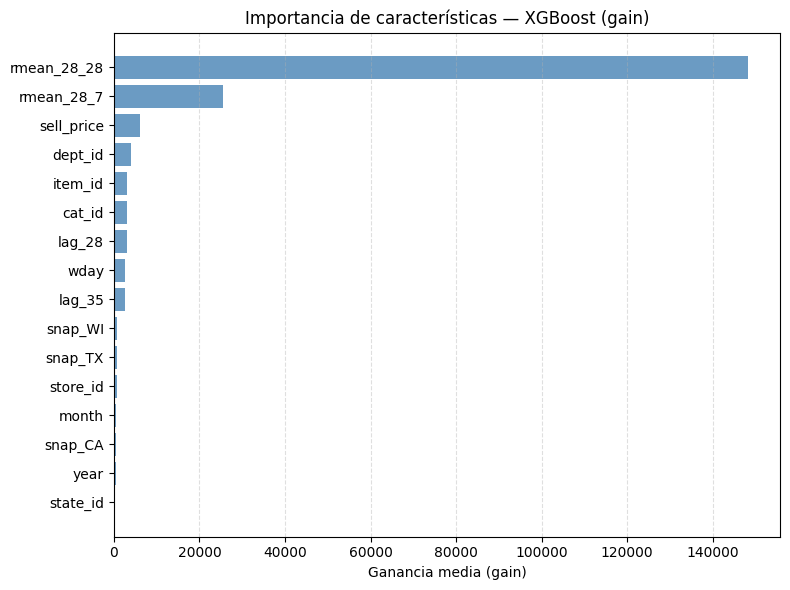

In [25]:
importancia = pd.DataFrame({
    'feature':    list(model.get_score(importance_type='gain').keys()),
    'importance': list(model.get_score(importance_type='gain').values())
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importancia['feature'], importancia['importance'], color='steelblue', alpha=0.8)
plt.title('Importancia de características — XGBoost (gain)')
plt.xlabel('Ganancia media (gain)')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 7.1.3 Visualización — Predicción frente a realidad

Se representan gráficamente las predicciones del modelo frente a las ventas reales observadas en el horizonte de validación, agregadas a nivel corporativo. La visualización permite inspeccionar de forma directa la capacidad del modelo para capturar la tendencia, los ciclos semanales y los picos extremos.

Esta representación complementa el RMSE con información cualitativa: dos modelos con RMSE similar pueden tener comportamientos muy distintos en términos de captura de picos, sesgo sistemático o desfase temporal, aspectos que el RMSE agregado no recoge.


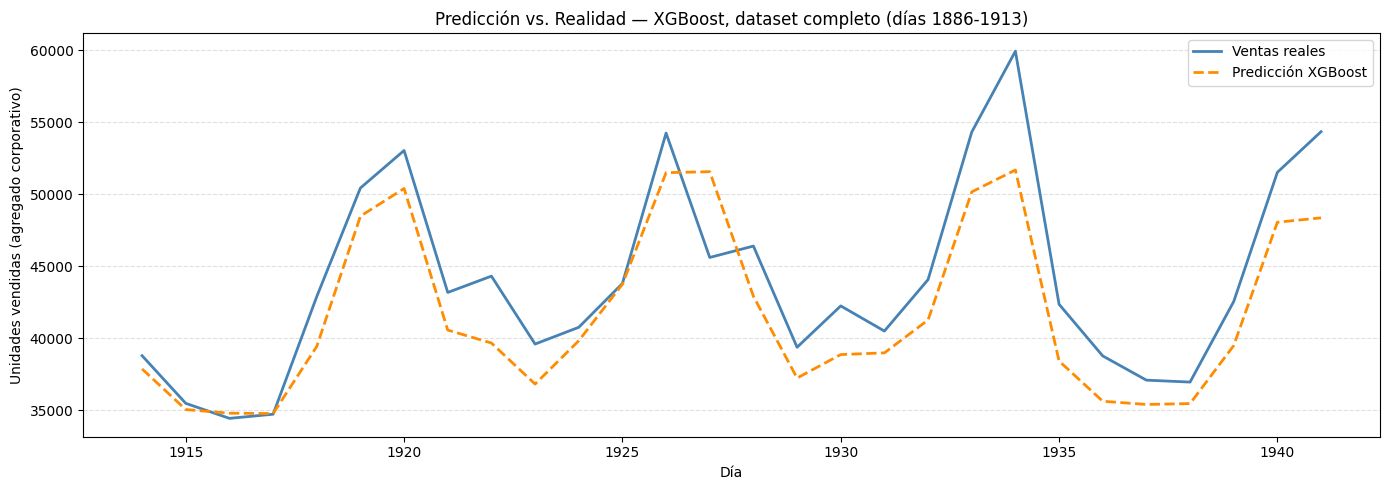

In [26]:
# Se agregan las predicciones y ventas reales por día
dias_valid  = list(range(VALID_START_DAY, VALID_END_DAY + 1))
n_series    = len(dias_valid)
obs_por_dia = len(y_valid) // n_series

reales_agg = y_valid.values.reshape(obs_por_dia, n_series).sum(axis=0)
preds_agg  = xgb_preds.reshape(obs_por_dia, n_series).sum(axis=0)

plt.figure(figsize=(14, 5))
plt.plot(dias_valid, reales_agg, label='Ventas reales',    color='steelblue',  linewidth=2)
plt.plot(dias_valid, preds_agg,  label='Predicción XGBoost', color='darkorange', linewidth=2, linestyle='--')
plt.title('Predicción vs. Realidad — XGBoost, dataset completo (días 1886-1913)')
plt.xlabel('Día')
plt.ylabel('Unidades vendidas (agregado corporativo)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 7.2 Prophet sobre el dataset completo

Se aplica Prophet a escala corporativa **agregando las 30.490 series en una única serie temporal diaria** (suma de las ventas de todos los SKUs cada día). A diferencia de XGBoost, que opera nativamente a nivel SKU, Prophet modela la demanda agregada del conjunto, lo que implica una pérdida de granularidad pero permite una comparación directa a nivel corporativo.

Conviene destacar que esta es una **limitación metodológica relevante**: XGBoost predice cada una de las 30.490 series individuales y posteriormente sus predicciones se agregan, mientras que Prophet predice directamente la serie ya agregada. La diferencia conceptual implica que ambos modelos están resolviendo problemas distintos aunque su evaluación se realice sobre la misma magnitud. La discusión completa de esta asimetría se desarrolla en el apartado 5.5 de la memoria escrita.

A esta escala se activa adicionalmente la estacionalidad anual (`yearly_seasonality=True`), dado que el volumen de datos a nivel corporativo permite estimar de forma estable los ciclos anuales.


In [27]:
from prophet import Prophet

# Agregamos todas las series por día para obtener la demanda corporativa
sales_raw = pd.read_csv(BASE + 'sales_train_evaluation.csv')
dia_cols    = [col for col in sales_raw.columns if col.startswith('d_')]
serie_total = sales_raw[dia_cols].sum()

del sales_raw
gc.collect()

df_prophet_total = pd.DataFrame({
    'ds': pd.date_range(start='2011-01-29', periods=len(serie_total), freq='D'),
    'd':  range(1, len(serie_total) + 1),
    'y':  serie_total.values
})

train_total = df_prophet_total[df_prophet_total['d'] <= TRAIN_END_DAY]
valid_total = df_prophet_total[df_prophet_total['d'] > TRAIN_END_DAY]

modelo_prophet_total = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)

modelo_prophet_total.fit(train_total[['ds', 'y']])

futuro_total  = modelo_prophet_total.make_future_dataframe(periods=28)
forecast_total = modelo_prophet_total.predict(futuro_total)

prophet_preds_total = forecast_total.tail(28)['yhat'].values

rmse_prophet_completo = np.sqrt(mean_squared_error(valid_total['y'].values, prophet_preds_total))
print(f"RMSE Prophet  — dataset completo: {rmse_prophet_completo:.4f}")

10:52:02 - cmdstanpy - INFO - Chain [1] start processing
10:52:02 - cmdstanpy - INFO - Chain [1] done processing


RMSE Prophet  — dataset completo: 4627.8717


In [36]:
# === 1. DATOS REALES Y NAIVE AGREGADO ===
sales_raw = pd.read_csv(BASE + 'sales_train_evaluation.csv')

# Predicciones Naive (copiar las ventas agregadas de hace 28 días)
dia_cols_naive = [f'd_{i}' for i in range(VALID_START_DAY - 28, VALID_END_DAY - 28 + 1)]
naive_agg = sales_raw[dia_cols_naive].sum(axis=0).values

# Ventas reales agregadas para la validación/evaluación
dia_cols_reales = [f'd_{i}' for i in range(VALID_START_DAY, VALID_END_DAY + 1)]
reales_agg_total = sales_raw[dia_cols_reales].sum(axis=0).values

# Liberar memoria
del sales_raw
gc.collect()

# Calcular RMSE Naive agregado
rmse_naive_agg = np.sqrt(mean_squared_error(reales_agg_total, naive_agg))


# === 2. XGBOOST AGREGADO ===
# XGBoost se predijo a nivel SKU, así que hay que sumar las predicciones por día
num_dias = VALID_END_DAY - VALID_START_DAY + 1  # Esto debe ser 28
xgb_preds_matrix = xgb_preds.reshape(-1, num_dias)
xgb_agg = xgb_preds_matrix.sum(axis=0)

# Calcular RMSE XGBoost agregado
rmse_xgb_agg = np.sqrt(mean_squared_error(reales_agg_total, xgb_agg))


# === 3. PROPHET AGREGADO ===
# Prophet ya se predijo a nivel agregado en tu celda anterior, 
# la variable prophet_preds_total ya está lista para usarse.
rmse_prophet_agg = np.sqrt(mean_squared_error(reales_agg_total, prophet_preds_total))


# === 4. CÁLCULO DE MEJORAS Y RESULTADOS ===
mejora_xgb     = (rmse_naive_agg - rmse_xgb_agg)     / rmse_naive_agg * 100
mejora_prophet = (rmse_naive_agg - rmse_prophet_agg) / rmse_naive_agg * 100

print(f"RMSE Naive    agregado: {rmse_naive_agg:.2f}")
print(f"RMSE XGBoost  agregado: {rmse_xgb_agg:.2f}  ({mejora_xgb:.1f}% mejora vs Naive)")
print(f"RMSE Prophet  agregado: {rmse_prophet_agg:.2f}  ({mejora_prophet:.1f}% mejora vs Naive)")

RMSE Naive    agregado: 3726.84
RMSE XGBoost  agregado: 3352.97  (10.0% mejora vs Naive)
RMSE Prophet  agregado: 4627.87  (-24.2% mejora vs Naive)


---

# 8. Comparación Final de Modelos

Se presenta el resumen comparativo de los cinco modelos evaluados sobre los dos planos de análisis: serie agregada de la tienda CA_1 y dataset corporativo completo. La visualización integra tres paneles:

- **Panel superior izquierdo:** RMSE de los cinco modelos sobre CA_1.
- **Panel superior derecho:** RMSE de los tres modelos directamente comparables sobre el dataset corporativo agregado (XGBoost, Naive Estacional, Prophet).
- **Panel inferior:** comparativa diaria entre las ventas reales y las predicciones de cada modelo sobre los 28 días del horizonte de evaluación a nivel corporativo.

La interpretación detallada y la discusión del hallazgo metodológico central se desarrollan en el apartado 5.5 de la memoria escrita.


=== TABLA 1: Serie agregada CA_1 ===
             Modelo        RMSE  Mejora vs Naive (%)  Error relativo (%)
1            SARIMA  388.255072                10.44                8.11
2           XGBoost  397.097870                 8.40                8.30
3  Naive Estacional  433.527928                 0.00                9.06
4           Prophet  500.152060               -15.37               10.45
5             ARIMA  825.771159               -90.48               17.25

Media ventas diarias CA_1: 4787 unidades

=== TABLA 2: Dataset completo (30.490 series) ===
             Modelo         RMSE  Mejora vs Naive (%)  Error relativo (%)
1           XGBoost  3352.973307                10.03                7.62
2  Naive Estacional  3726.837045                 0.00                8.47
3           Prophet  4627.871665               -24.18               10.52

Media ventas diarias agregadas: 43992 unidades


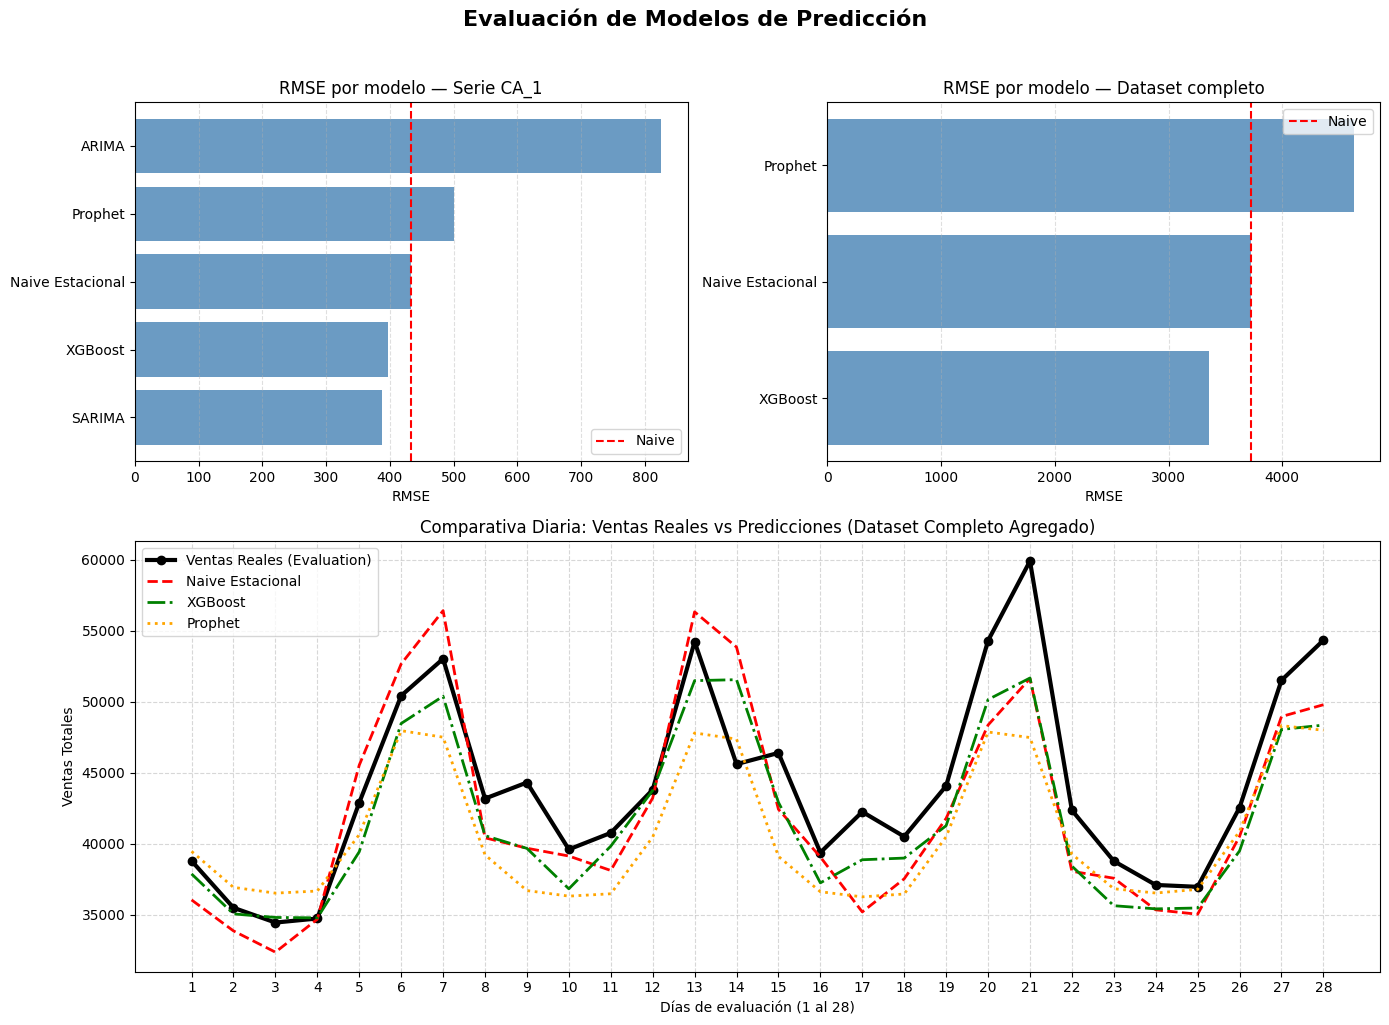

In [43]:
import matplotlib.gridspec as gridspec

# Media ventas reales CA_1 (28 días de evaluación)
sales_raw = pd.read_csv(BASE + 'sales_train_evaluation.csv')
dia_cols_reales = [f'd_{i}' for i in range(VALID_START_DAY, VALID_END_DAY + 1)]
reales_ca1 = sales_raw[sales_raw['store_id'] == 'CA_1'][dia_cols_reales].sum(axis=0).values
media_ca1 = reales_ca1.mean()

del sales_raw
gc.collect()

# Tabla comparativa CA_1 
tabla_ca1 = pd.DataFrame({
    'Modelo':  ['SARIMA', 'Naive Estacional', 'XGBoost', 'Prophet', 'ARIMA'],
    'RMSE':    [rmse_sarima, rmse_naive, rmse_xgb_ca1, rmse_prophet, rmse_arima]
}).sort_values('RMSE').reset_index(drop=True)

tabla_ca1.index += 1
tabla_ca1['Mejora vs Naive (%)'] = ((rmse_naive - tabla_ca1['RMSE']) / rmse_naive * 100).round(2)
tabla_ca1['Error relativo (%)']  = (tabla_ca1['RMSE'] / media_ca1 * 100).round(2)

# Tabla comparativa dataset completo 
media_completo_agg = reales_agg_total.mean()

tabla_completo = pd.DataFrame({
    'Modelo':  ['XGBoost', 'Naive Estacional', 'Prophet'],
    'RMSE':    [rmse_xgb_agg, rmse_naive_agg, rmse_prophet_agg]
}).sort_values('RMSE').reset_index(drop=True)

tabla_completo.index += 1
tabla_completo['Mejora vs Naive (%)'] = ((rmse_naive_agg - tabla_completo['RMSE']) / rmse_naive_agg * 100).round(2)
tabla_completo['Error relativo (%)']  = (tabla_completo['RMSE'] / media_completo_agg * 100).round(2)

print("=== TABLA 1: Serie agregada CA_1 ===")
print(tabla_ca1.to_string())
print(f"\nMedia ventas diarias CA_1: {media_ca1:.0f} unidades")
print("\n=== TABLA 2: Dataset completo (30.490 series) ===")
print(tabla_completo.to_string())
print(f"\nMedia ventas diarias agregadas: {media_completo_agg:.0f} unidades")

# Gráfico comparativo final 
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2])

ax0 = fig.add_subplot(gs[0, 0])
ax0.barh(tabla_ca1['Modelo'], tabla_ca1['RMSE'], color='steelblue', alpha=0.8)
ax0.axvline(x=rmse_naive, color='red', linestyle='--', linewidth=1.5, label='Naive')
ax0.set_title('RMSE por modelo — Serie CA_1')
ax0.set_xlabel('RMSE')
ax0.legend(loc='lower right')
ax0.grid(axis='x', linestyle='--', alpha=0.4)

ax1 = fig.add_subplot(gs[0, 1])
ax1.barh(tabla_completo['Modelo'], tabla_completo['RMSE'], color='steelblue', alpha=0.8)
ax1.axvline(x=rmse_naive_agg, color='red', linestyle='--', linewidth=1.5, label='Naive')
ax1.set_title('RMSE por modelo — Dataset completo')
ax1.set_xlabel('RMSE')
ax1.legend(loc='upper right')
ax1.grid(axis='x', linestyle='--', alpha=0.4)

ax2 = fig.add_subplot(gs[1, :])
dias = range(1, 29) 

ax2.plot(dias, reales_agg_total, color='black', linewidth=3, marker='o', label='Ventas Reales (Evaluation)')
ax2.plot(dias, naive_agg, color='red', linestyle='--', linewidth=2, label='Naive Estacional')
ax2.plot(dias, xgb_agg, color='green', linestyle='-.', linewidth=2, label='XGBoost')
ax2.plot(dias, prophet_preds_total, color='orange', linestyle=':', linewidth=2, label='Prophet')

ax2.set_title('Comparativa Diaria: Ventas Reales vs Predicciones (Dataset Completo Agregado)')
ax2.set_xlabel('Días de evaluación (1 al 28)')
ax2.set_ylabel('Ventas Totales')
ax2.set_xticks(dias)
ax2.legend(loc='upper left')
ax2.grid(linestyle='--', alpha=0.5)

plt.suptitle('Evaluación de Modelos de Predicción', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()